## Education Pathway and Long-Term Job Satisfaction
### Swiss TREE1 Longitudinal Study (2001-2019)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Loading Data

In [2]:
pisa = pd.read_stata("data/PISA_TREE1_2000_version_2025.dta")
pisa.head()

,id,stratum,school,student,valid,st01q02,st01q03,st02q01,st04q01,st04q02,...,st45q05bfs,st45q07bfs,sex,canton,reg_ling,agglo,typ,wlerlev,sample,schauton
0,11001001,Dt.-CH BE 9. Schuljahr öffentlich sehr klein,11001,1,gültig,3,1985,9.0,Yes,No,...,NaN,NaN,female,be,German,rural area,basic academic requirements,high,sample,NaN
1,11001002,Dt.-CH BE 9. Schuljahr öffentlich sehr klein,11001,2,gültig,1,1985,9.0,Yes,No,...,NaN,NaN,female,be,German,rural area,basic academic requirements,medium high,sample,NaN
2,11001003,Dt.-CH BE 9. Schuljahr öffentlich sehr klein,11001,3,gültig,4,1983,9.0,Yes,No,...,Automechaniker/in,NaN,male,be,German,rural area,basic academic requirements,very low,sample,NaN
3,11002002,Dt.-CH BE 9. Schuljahr öffentlich sehr klein,11002,2,gültig,11,1984,9.0,Yes,No,...,NaN,NaN,male,be,German,urban area/agglomeration,extended academic requirements,medium high,sample,-0.29
4,11002003,Dt.-CH BE 9. Schuljahr öffentlich sehr klein,11002,3,gültig,5,1984,9.0,Yes,No,...,NaN,NaN,male,be,German,urban area/agglomeration,pre-gymnasial,medium high,sample,-0.29


In [3]:
wave3 = pd.read_stata("data/TREE1_data_wave_3_2003_version_2025.dta")
wave4 = pd.read_stata("data/TREE1_data_wave_4_2004_version_2025.dta")
wave5 = pd.read_stata("data/TREE1_data_wave_5_2005_version_2025.dta")
wave7 = pd.read_stata("data/TREE1_data_wave_7_2007_version_2025.dta")
wave8 = pd.read_stata("data/TREE1_data_wave_8_2010_version_2025.dta")
wave9 = pd.read_stata("data/TREE1_data_wave_9_2014_version_2025.dta")
wave10 = pd.read_stata("data/TREE1_data_wave_10_2019_version_2025.dta")

### Cleaning and Combining Data

Waves 1-2 do not have job satisfaction columns, so we start from wave 3.  
Wave 10 resignative satisfaction uses a different scale, so we exclude it from resignative analysis.

In [4]:
wave3_clean = wave3[wave3['t3valids'] == 'valid'][['id', 't3educ22_1', 't3jsag1', 't3jsar1']].copy()
wave3_clean.columns = ['id', 'education', 'genuine_sat', 'resignative_sat']
wave3_clean['wave'] = 3
wave3_clean['year'] = 2003

wave4_clean = wave4[wave4['t4valids'] == 'valid'][['id', 't4educ22_1', 't4jsag1', 't4jsar1']].copy()
wave4_clean.columns = ['id', 'education', 'genuine_sat', 'resignative_sat']
wave4_clean['wave'] = 4
wave4_clean['year'] = 2004

wave5_clean = wave5[wave5['t5valids'] == 'valid'][['id', 't5educ22_1', 't5jsag1', 't5jsar1']].copy()
wave5_clean.columns = ['id', 'education', 'genuine_sat', 'resignative_sat']
wave5_clean['wave'] = 5
wave5_clean['year'] = 2005

wave7_clean = wave7[wave7['t7valids'] == 'valid'][['id', 't7educ22_1', 't7jsag1', 't7jsar1']].copy()
wave7_clean.columns = ['id', 'education', 'genuine_sat', 'resignative_sat']
wave7_clean['wave'] = 7
wave7_clean['year'] = 2007

wave8_clean = wave8[wave8['t8valids'] == 'valid'][['id', 't8educ22_1', 't8jsag1', 't8jsar1']].copy()
wave8_clean.columns = ['id', 'education', 'genuine_sat', 'resignative_sat']
wave8_clean['wave'] = 8
wave8_clean['year'] = 2010

wave9_clean = wave9[wave9['t9valids'] == 'valid'][['id', 't9educ22_1', 't9jsag1', 't9jsar1']].copy()
wave9_clean.columns = ['id', 'education', 'genuine_sat', 'resignative_sat']
wave9_clean['wave'] = 9
wave9_clean['year'] = 2014

wave10_clean = wave10[wave10['t10valids'] == 'valid'][['id', 't10educ22_1', 't10jsag1']].copy()
wave10_clean.columns = ['id', 'education', 'genuine_sat']
wave10_clean['resignative_sat'] = np.nan
wave10_clean['wave'] = 10
wave10_clean['year'] = 2019

all_waves = pd.concat([wave3_clean, wave4_clean, wave5_clean, wave7_clean,
                        wave8_clean, wave9_clean, wave10_clean], ignore_index=True)
all_waves.head()

,id,education,genuine_sat,resignative_sat,wave,year
0,11006006,NaN,6.5,NaN,3,2003
1,12004009,NaN,NaN,NaN,3,2003
2,13001024,NaN,very satisfied,hardly ever,3,2003
3,13001030,NaN,NaN,NaN,3,2003
4,13001034,NaN,NaN,NaN,3,2003


### Recoding Education Pathways

In [5]:
pathway_map = {
    'apprenticeship with federal diploma of vocational education and training, or equivalent (3 or 4 years)': 'VET Apprenticeship',
    'apprenticeship with federal diploma of vocational education and training (Eidgenössisches Fähigkeitszeugnis) or equivalent (3 or 4 years)': 'VET Apprenticeship',
    'apprenticeship with basic federal certificate of vocational education and training (2years)(Berufsattest)': 'VET Apprenticeship',
    'commercial college (WMS)': 'VET Apprenticeship',
    'higher vocational education and training (Advanced Federal Certificate/Federal Diploma of Higher VET)': 'Higher VET',
    'higher specialised school': 'Higher VET',
    'professional baccalaureate/vocational matura (full time after education)': 'Higher VET',
    'universities and federal institutes of technology (ETH)(Bachelor/Master/Diploma)': 'University',
    'universities and federal institutes of technology (ETH) (Bachelor/Master/Diploma)': 'University',
    'university of applied sciences/universities of teacher education (Bachelor)': 'University',
    'postgraduate studies': 'University',
    'post-graduate studies': 'University',
    'PhD': 'University',
    'Professional academic specialisation / examination': 'University',
    'Professional academic specialisation/examination': 'University',
    'teachers college (kindergarten/primary)': 'University',
    'academic matura school': 'General Upper Secondary',
    'specialised middle schools (FMS/DMS)': 'General Upper Secondary',
    'specialised matura (FMS/DMS)': 'General Upper Secondary',
    'pre-course (in order to enter higher education)': 'General Upper Secondary',
}

all_waves['pathway'] = all_waves['education'].map(pathway_map)
all_waves = all_waves.dropna(subset=['pathway'])
all_waves['pathway'].value_counts()

VET Apprenticeship         5305
University                 4355
General Upper Secondary    3393
Higher VET                 1148
Name: pathway, dtype: int64

### Recoding Satisfaction Scores to Numbers

In [6]:
genuine_map = {
    'extraordinarily satisfied': 6, 'very satisfied': 5,
    'rather satisfied': 4, 'so, so': 3,
    'rather dissatisfied': 2, 'very dissatisfied': 1,
    'extraordinarily dissatisfied': 0,
}

resignative_map = {
    'hardly ever': 1, 'very scarcely': 2, 'rather scarcely': 3,
    'every now and then': 4, ' every now and then': 4,
    'rather often': 5, 'very often': 6, 'almost ever': 7,
}

all_waves['genuine_score'] = all_waves['genuine_sat'].map(genuine_map)
all_waves['resignative_score'] = all_waves['resignative_sat'].map(resignative_map)

all_waves.head()

,id,education,genuine_sat,resignative_sat,wave,year,pathway,genuine_score,resignative_score
239,11001001,apprenticeship with federal diploma of vocatio...,NaN,NaN,3,2003,VET Apprenticeship,NaN,NaN
240,11001002,apprenticeship with federal diploma of vocatio...,NaN,NaN,3,2003,VET Apprenticeship,NaN,NaN
241,11002002,apprenticeship with federal diploma of vocatio...,NaN,NaN,3,2003,VET Apprenticeship,NaN,NaN
243,11002005,apprenticeship with federal diploma of vocatio...,NaN,NaN,3,2003,VET Apprenticeship,NaN,NaN
244,11002006,apprenticeship with federal diploma of vocatio...,NaN,NaN,3,2003,VET Apprenticeship,NaN,NaN


### Adding Gender from PISA Data

In [7]:
pisa_gender = pisa[['id', 'sex']].copy()
all_waves = all_waves.merge(pisa_gender, on='id', how='left')
all_waves['sex'].value_counts()

female    7974
male      6227
Name: sex, dtype: int64

In [8]:
print("Total records:", len(all_waves))
print("Unique people:", all_waves['id'].nunique())
print("\nRecords per pathway:")
print(all_waves['pathway'].value_counts())
print("\nRecords per year:")
print(all_waves.groupby('year')['id'].count())

Total records: 14201
Unique people: 4993

Records per pathway:
VET Apprenticeship         5305
University                 4355
General Upper Secondary    3393
Higher VET                 1148
Name: pathway, dtype: int64

Records per year:
year
2003    4569
2004    3376
2005    2482
2007    2136
2010    1134
2014     504
Name: id, dtype: int64


## RQ1: How does job satisfaction differ by education pathway?

### Figure 1: Genuine Job Satisfaction by Education Pathway

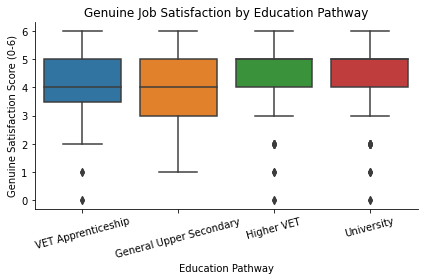

In [9]:
sns.boxplot(data=all_waves, x='pathway', y='genuine_score')
plt.xlabel('Education Pathway')
plt.ylabel('Genuine Satisfaction Score (0-6)')
plt.title('Genuine Job Satisfaction by Education Pathway')
plt.xticks(rotation=15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_genuine_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 2: Resignative Satisfaction by Education Pathway

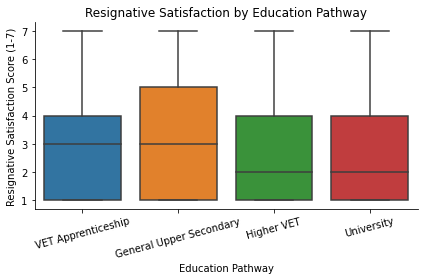

In [10]:
sns.boxplot(data=all_waves.dropna(subset=['resignative_score']),
            x='pathway', y='resignative_score')
plt.xlabel('Education Pathway')
plt.ylabel('Resignative Satisfaction Score (1-7)')
plt.title('Resignative Satisfaction by Education Pathway')
plt.xticks(rotation=15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_resignative_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3: Genuine vs. Resignative Satisfaction

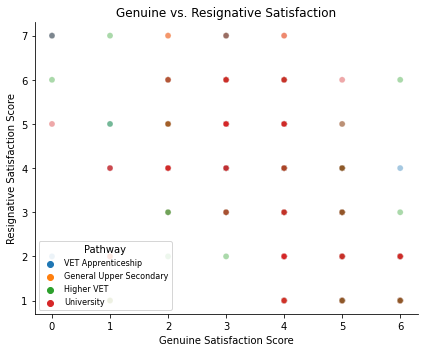

In [11]:
scatter_data = all_waves.dropna(subset=['genuine_score', 'resignative_score'])

plt.figure(figsize=(6, 5))
sns.scatterplot(data=scatter_data, x='genuine_score', y='resignative_score',
                hue='pathway', alpha=0.4)
plt.xlabel('Genuine Satisfaction Score')
plt.ylabel('Resignative Satisfaction Score')
plt.title('Genuine vs. Resignative Satisfaction')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(title='Pathway', fontsize=8)
plt.tight_layout()
plt.savefig('fig3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4: Genuine Satisfaction by Pathway and Gender

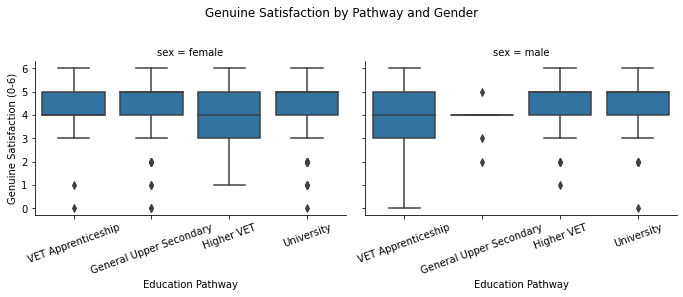

In [21]:
g = sns.FacetGrid(all_waves.dropna(subset=['sex', 'genuine_score']),
                  col='sex', height=4, aspect=1.2)
g.map(sns.boxplot, 'pathway', 'genuine_score')
g.fig.suptitle('Genuine Satisfaction by Pathway and Gender', y=1.02)
g.set_axis_labels('Education Pathway', 'Genuine Satisfaction (0-6)')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_genuine_gender.png', dpi=150, bbox_inches='tight')
plt.show()

## RQ2: How do pathway-based satisfaction differences change over time (2001-2019)?

### Figure 5: Genuine Satisfaction Over Time

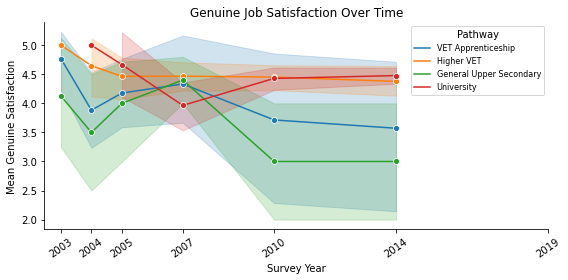

In [13]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=all_waves.dropna(subset=['genuine_score']),
             x='year', y='genuine_score', hue='pathway', marker='o')
plt.xlabel('Survey Year')
plt.ylabel('Mean Genuine Satisfaction')
plt.title('Genuine Job Satisfaction Over Time')
plt.xticks([2003,2004,2005,2007,2010,2014,2019], rotation=35)
plt.legend(title='Pathway', fontsize=8)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_genuine_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 6: Resignative Satisfaction Over Time

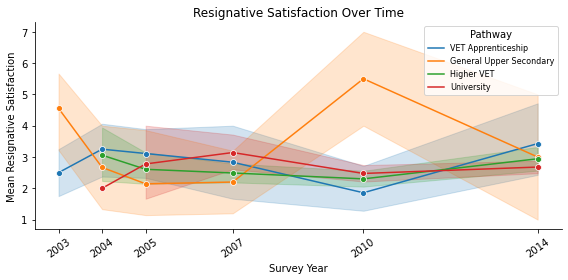

In [14]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=all_waves.dropna(subset=['resignative_score']),
             x='year', y='resignative_score', hue='pathway', marker='o')
plt.xlabel('Survey Year')
plt.ylabel('Mean Resignative Satisfaction')
plt.title('Resignative Satisfaction Over Time')
plt.xticks([2003,2004,2005,2007,2010,2014], rotation=35)
plt.legend(title='Pathway', fontsize=8)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_resignative_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 7: Genuine Satisfaction Distribution by Year (Small Multiples)

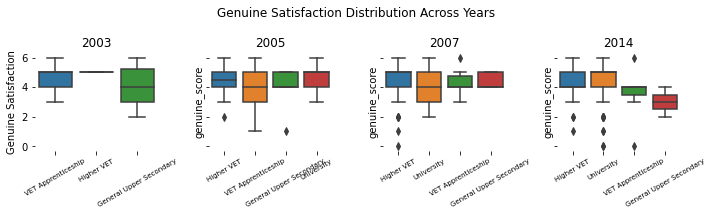

In [16]:
years = [2003, 2005, 2007, 2014]

fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(10, 3), sharey=True)
fig.suptitle('Genuine Satisfaction Distribution Across Years')

for i, y in enumerate(years):
    ax = axes[i]
    year_data = all_waves[(all_waves['year'] == y) & (all_waves['genuine_score'].notna())]
    sns.boxplot(data=year_data, x='pathway', y='genuine_score', ax=ax)
    ax.set_title(str(y))
    ax.set_xlabel('')
    
    current_labels = ax.get_xticklabels()
    label_mapping = {'VET': 'VET', 'Gen.': 'Gen.', 'Uni.': 'Uni.', 'H.VET': 'H.VET'}
    
    new_labels = []
    for label in current_labels:
        original_text = label.get_text()
        new_labels.append(label_mapping.get(original_text, original_text))
    
    ax.set_xticklabels(new_labels, fontsize=7, rotation=30)

    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('Genuine Satisfaction')
fig.tight_layout()
plt.savefig('fig7_small_multiples.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 8: Resignative Satisfaction by Pathway and Gender

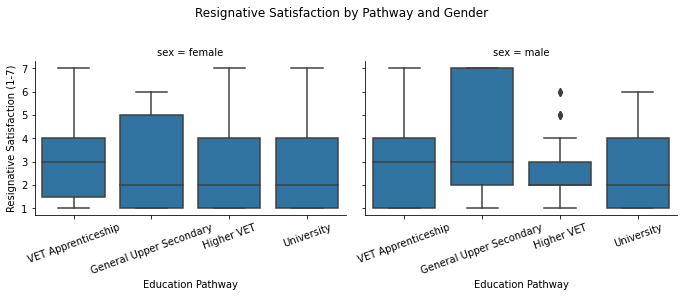

In [17]:
g = sns.FacetGrid(all_waves.dropna(subset=['sex', 'resignative_score']),
                  col='sex', height=4, aspect=1.2)
g.map(sns.boxplot, 'pathway', 'resignative_score')
g.fig.suptitle('Resignative Satisfaction by Pathway and Gender', y=1.02)
g.set_axis_labels('Education Pathway', 'Resignative Satisfaction (1-7)')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig8_resignative_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 9: Distribution of Genuine Satisfaction Scores

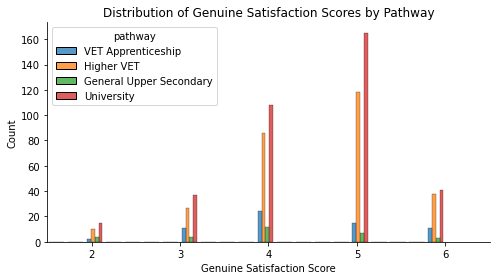

In [18]:
plt.figure(figsize=(7, 4))
sns.histplot(data=all_waves.dropna(subset=['genuine_score']),
             x='genuine_score', hue='pathway', multiple='dodge', shrink=0.8)
plt.xlabel('Genuine Satisfaction Score')
plt.ylabel('Count')
plt.title('Distribution of Genuine Satisfaction Scores by Pathway')
plt.xlim(1.5, 6.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig9_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 10: Heatmap of Mean Genuine Satisfaction by Pathway and Year

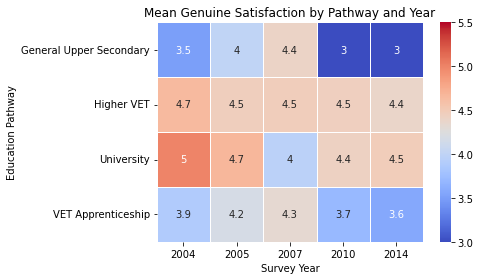

In [19]:
heatmap_data = (all_waves[(all_waves['genuine_score'].notna()) & (~all_waves['year'].isin([2003, 2019]))]
                .groupby(['pathway', 'year'])['genuine_score']
                .mean()
                .unstack()
                .round(2))

plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, linewidths=0.5,
            vmin=3, vmax=5.5)
plt.title('Mean Genuine Satisfaction by Pathway and Year')
plt.ylabel('Education Pathway')
plt.xlabel('Survey Year')
plt.tight_layout()
plt.savefig('fig10_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary Statistics

In [20]:
all_waves.groupby('pathway')[['genuine_score', 'resignative_score']].describe().round(2)

genuine_score                                       \
                                count  mean   std  min  25%  50%  75%  max   
pathway                                                                      
General Upper Secondary          32.0  3.84  1.35  1.0  3.0  4.0  5.0  6.0   
Higher VET                      284.0  4.46  1.09  0.0  4.0  5.0  5.0  6.0   
University                      372.0  4.43  1.07  0.0  4.0  5.0  5.0  6.0   
VET Apprenticeship               67.0  4.12  1.39  0.0  3.5  4.0  5.0  6.0   

                        resignative_score                                       
                                    count  mean   std  min  25%  50%  75%  max  
pathway                                                                         
General Upper Secondary              31.0  3.23  2.16  1.0  1.0  3.0  5.0  7.0  
Higher VET                          281.0  2.56  1.45  1.0  1.0  2.0  4.0  7.0  
University                          378.0  2.65  1.54  1.0  1.0  2.0  4.0  7.0  
VET Apprenticeship                   66.0  2.91  1.61  1.0  1.0  3.0  4.0  7.0

### References

1. Gomensoro, A., & Meyer, T. (2017). TREE (Transitions from Education to Employment): A Swiss Multi-Cohort Survey. *Longitudinal and Life Course Studies*, 8(2), 209-224. https://doi.org/10.14301/llcs.v8i2.424

2. OECD. (2001). *Knowledge and Skills for Life: First Results from PISA 2000*. OECD Publishing. https://doi.org/10.1787/9789264195066-en

3. Stalder, B. E., Meyer, T., & Hupka-Brunner, S. (2011). TREE Project: A longitudinal study of the transition from education to employment in Switzerland. In S. Bergman et al. (Eds.), *Youth Transitions in Switzerland: Results from the TREE Panel Study* (pp. 9-21). Seismo Press.

4. Wolter, S. C., & Ryan, P. (2011). Apprenticeship. In E. A. Hanushek, S. Machin, & L. Woessmann (Eds.), *Handbook of the Economics of Education* (Vol. 3, pp. 521-576). Elsevier. https://doi.org/10.1016/B978-0-444-53429-3.00011-9

5. Messersmith, E. E., Garrett, J. L., Davis-Kean, P. E., Malanchuk, O., & Eccles, J. S. (2008). Career development from adolescence through emerging adulthood. *Journal of Adolescent Research*, 23(2), 206-227. https://doi.org/10.1177/0743558407310723